# Binary Classifier on MNIST Dataset

Trying to build a Binary Classifier with some instructions.
### What's a Binary Classifier?
A binary classifier is a machine learning model that predicts one of two possible outcomes. In this notebook, we use an SGDClassifier to distinguish between a specific digit (e.g., 2) and all other digits in the MNIST dataset. The model learns to classify each 28×28 pixel image as either the target digit or not the target digit, making it a binary classification task.

> **Tutorial/Instructions I followed**:  
> - Chapter 3: Classification **->** from *[Hands on Machine Learning](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)*

## Description of the Dataset
(I'll forgive you if you wanna skip this)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image by computing the center of mass of the pixels, and translating the image so as to position this point at the center of the 28x28 field.  

With some classification methods (particularly template-based methods, such as SVM and K-nearest neighbors), the error rate improves when the digits are centered by bounding box rather than center of mass. If you do this kind of pre-processing, you should report it in your publications. The MNIST database was constructed from NIST's NIST originally designated SD-3 as their training set and SD-1 as their test set. However, SD-3 is much cleaner and easier to recognize than SD-1. The reason for this can be found on the fact that SD-3 was collected among Census Bureau employees, while SD-1 was collected among high-school students. Drawing sensible conclusions from learning experiments requires that the result be independent of the choice of training set and test among the complete set of samples. Therefore it was necessary to build a new database by mixing NIST's datasets.  

The MNIST training set is composed of 30,000 patterns from SD-3 and 30,000 patterns from SD-1. Our test set was composed of 5,000 patterns from SD-3 and 5,000 patterns from SD-1. The 60,000 pattern training set contained examples from approximately 250 writers. We made sure that the sets of writers of the training set and test set were disjoint. SD-1 contains 58,527 digit images written by 500 different writers. In contrast to SD-3, where blocks of data from each writer appeared in sequence, the data in SD-1 is scrambled. Writer identities for SD-1 is available and we used this information to unscramble the writers. We then split SD-1 in two: characters written by the first 250 writers went into our new training set. The remaining 250 writers were placed in our test set. Thus we had two sets with nearly 30,000 examples each. The new training set was completed with enough examples from SD-3, starting at pattern # 0, to make a full set of 60,000 training patterns. Similarly, the new test set was completed with SD-3 examples starting at pattern # 35,000 to make a full set with 60,000 test patterns. Only a subset of 10,000 test images (5,000 from SD-1 and 5,000 from SD-3) is available on this site. The full 60,000 sample training set is available.

Downloaded from openml.org.

In [23]:
# imports
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve

In [24]:
# disable warnings
import warnings
warnings.filterwarnings('ignore')

---
## 1. Import & Preview the Data

In [25]:
# get the data

# btw fetch_openml is an experimental function at this time...
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

So we received a dictionary containing our data in key-value pairs such as:
- `DESCR` → Description. → [Discription of the Dataset](#description-of-the-dataset)
- `data` → Features.
- `target` → Labels.  
and others...

In [26]:
# splitting stuff
X, y = mnist["data"], mnist["target"]
y = y.astype(np.uint8) # y.dtype should be int, not object

print("Features shape:", X.shape)
print("Label shape:   " ,y.shape)

Features shape: (70000, 784)
Label shape:    (70000,)


In [27]:
# let's choose a random digit index
random_index = 5  # you can change it but default = 5

our_digit = X.iloc[random_index, :]
print("\033[1;35mYou chose: \033[0m", y[random_index])

You chose:  2


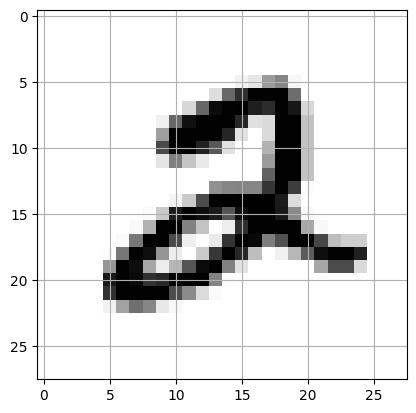

In [28]:
# VISUALISATION
our_digit_image = our_digit.values.reshape(28,28)

plt.imshow(our_digit_image, cmap=cm.binary, interpolation="nearest")
plt.grid()
plt.show()

---
## 2. Binary Classifier

Before we start, let's split the data.  
A lil birdie told me it's already shuffled, which means we don't need `train_test_split` method for this

In [29]:
# train test split
X_train, X_test, y_train, y_test = X[:60000 :], X[60000: :], y[:60000], y[60000:]

In [30]:
# we're gonna predict the same digit that we visualised
num: int = y[random_index]

y_train_num = (y_train == num)
y_test_num = (y_test == num)

In [31]:
# binary model
binary_clf = SGDClassifier(random_state=42)
binary_clf.fit(X_train, y_train_num)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


<span style="color:magenta; font-weight:bold;">Yay you built your binary classifier!!!</span>

In [32]:
# making predictions for the binary classification
binary_pred = cross_val_predict(binary_clf, X_train, y_train_num, cv=3)

### 2.1 Evaluation

There are 3 metrics to evaluate a classification model.
- **Precision:** The ratio of true positives to the total predicted positives; it measures how *"trustworthy"* the model is when it claims a positive result.
- **Recall:** The ratio of true positives to all actual positives; it measures the model's ability to find all relevant cases within the dataset.
- **F1-Score:** The harmonic mean of precision and recall, providing a single balanced metric that penalizes extreme values in either.

We'll also look at the confusion matrix.

<img alt="Confusion Matrix Diagram" src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*d0UCCIF10Soi7VQGxdVrWQ.jpeg" height=350px/>

In [33]:
# confusion matrix & scores
c_matrix = confusion_matrix(y_train_num, binary_pred)
precision = c_matrix[0,0] / (c_matrix[0,0] + c_matrix[0,1])
print("\033[1;32mConfusion Matrix:\n",
      c_matrix, "\33[0m\n") # ansii escape codes for coloring

print("Precision:", precision_score(y_train_num, binary_pred))
print("Recall:   ", recall_score(y_train_num, binary_pred))
print("F1 Score: ", f1_score(y_train_num, binary_pred))

Confusion Matrix:
 [[51538  2504]
 [  908  5050]] 

Precision: 0.6685199894095843
Recall:    0.8475998657267539
F1 Score:  0.7474837181764358


You may like to play around with this, but right now, our scores are as follows:  
(target **num = 2**, btw)  

> Confusion Matrix:  
> [[51538  2504]  
>  [  908  5050]]

> Precision: 0.6685199894095843  
> Recall:    0.8475998657267539  
> F1 Score:  0.7474837181764358  

- So when our binary model claims a digit to be the number, **it's only correct 66.8% of the time**.  
- It only **detects 84.7% of the total digits**.

### 2.2 Precision/Recall Tradeoff

> If someone says ❛Let's reach 99% precision❜, you should ask, ❛At what recall?❜  
> — saw it in the Chapter and wanted to share

In [34]:
# calculating precision recall curve
y_scores = cross_val_predict(binary_clf, X_train, y_train_num, cv=3, method='decision_function')
precisions, recalls, thresholds = precision_recall_curve(y_train_num, y_scores)

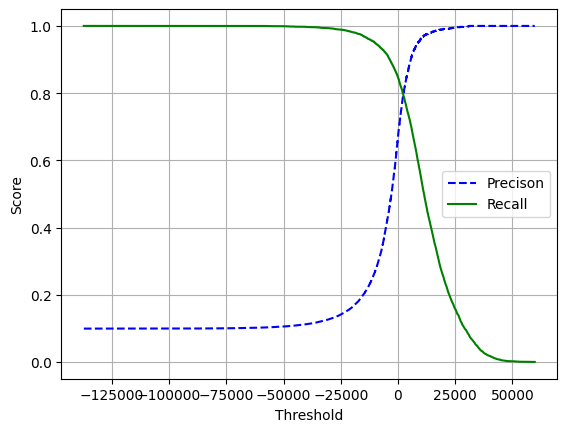

In [35]:
# VISUALISATION: creating a precision-recall curve
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precison')
    plt.plot(thresholds, recalls[:-1], "g-", label='Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()

plot_precision_recall_curve(precisions, recalls, thresholds)
plt.grid()
plt.show()

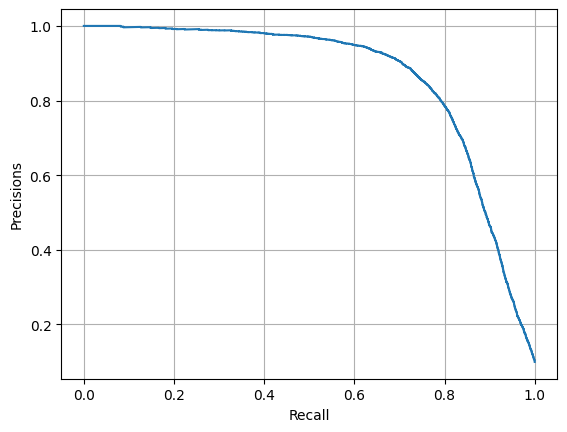

In [36]:
# VISUALISATION: precision vs recall
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precisions")

plt.grid()
plt.show()

I think the best trade-off we can get is both precision & recall around 79%. Let's get the threshold.

In [37]:
target_threshold = thresholds[np.argmax(precisions >= 0.79)] # ~2207.98

In [38]:
# new predictions using the threshold
y_train_new_pred = (y_scores >= target_threshold)

In [39]:
print("New precision score: ", precision_score(y_train_num, y_train_new_pred))
print("New recall score: ", recall_score(y_train_num, y_train_new_pred))

New precision score:  0.7900947315938175
New recall score:  0.7979187646861363


Better precision then the last time with a recall score cost